In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [ ]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [ ]:
skewed_cols = ['A', 'B', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
print("Descriptive statistics for highly skewed columns:")
print(df_raw[skewed_cols].describe())

Descriptive statistics for highly skewed columns:
              A         B         I         J         K         L         M         N         O         P
count 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000 1150.0000
mean     0.9965    0.9183   64.0920   23.1020    8.7107    1.8380    0.5612    0.2125    0.0857    0.0373
std      0.0589    0.2741   58.5105   21.6069   11.5708    3.9246    2.4851    1.0576    0.3989    0.1790
min      0.0000    0.0000    0.3493    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
25%      1.0000    1.0000   22.2690    7.9441    1.2424    0.0819    0.0000    0.0000    0.0000    0.0000
50%      1.0000    1.0000   44.2333   17.0416    4.4336    0.4849    0.0223    0.0016    0.0000    0.0000
75%      1.0000    1.0000   87.8391   31.3106   11.7756    1.9260    0.1924    0.0385    0.0048    0.0039
max      1.0000    1.0000  403.9391  167.1314  106.0701   59.7661   51.4232   20.0986    5.9378    3.0

In [ ]:
highly_correlated_pairs = [['C', 'D', 0.996], ['D', 'E', 0.994], ['E', 'F', 0.992], ['F', 'G', 0.988], ['C', 'E', 0.986]]

print("Correlations for highly correlated pairs:")
for pair in highly_correlated_pairs:
    col1, col2, _ = pair
    print(f"Correlation between {col1} and {col2}: {df_raw[col1].corr(df_raw[col2]):.3f}")

Correlations for highly correlated pairs:
Correlation between C and D: 0.996
Correlation between D and E: 0.994
Correlation between E and F: 0.992
Correlation between F and G: 0.988
Correlation between C and E: 0.986


In [ ]:
binary_cols = ['A', 'B', 'S', 'T']

print("Value counts for binary columns:")
for col in binary_cols:
    print(f"\nColumn: {col}")
    print(df_raw[col].value_counts(normalize=True))

Value counts for binary columns:

Column: A
A
1   0.9965
0   0.0035
Name: proportion, dtype: float64

Column: B
B
1   0.9183
0   0.0817
Name: proportion, dtype: float64

Column: S
S
0   0.6635
1   0.3365
Name: proportion, dtype: float64

Column: T
T
1   0.5313
0   0.4687
Name: proportion, dtype: float64


This heatmap visualizes the correlation between columns C, D, E, F, and G, revealing the strength and direction of their linear relationships.
These histograms show the distributions of highly skewed columns I, J, and K, illustrating their long tails and concentration of data points towards lower values.
These count plots display the frequency of each category within binary columns A and B, showing the distribution of their two distinct values.


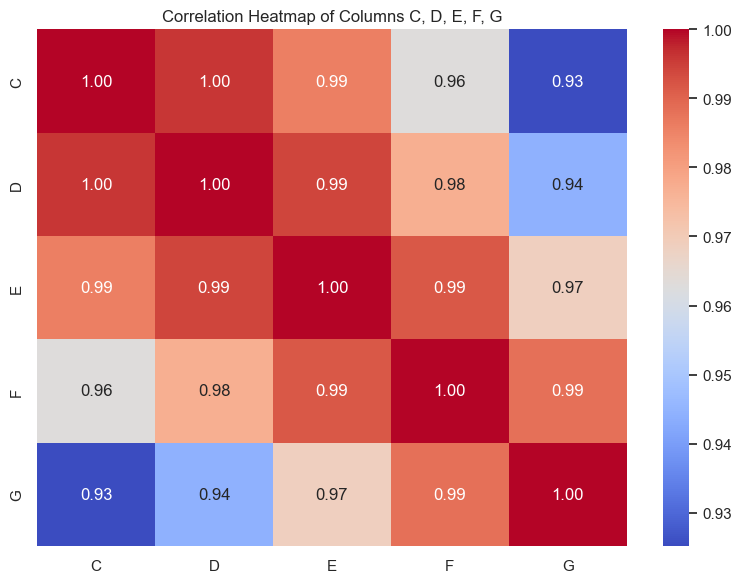

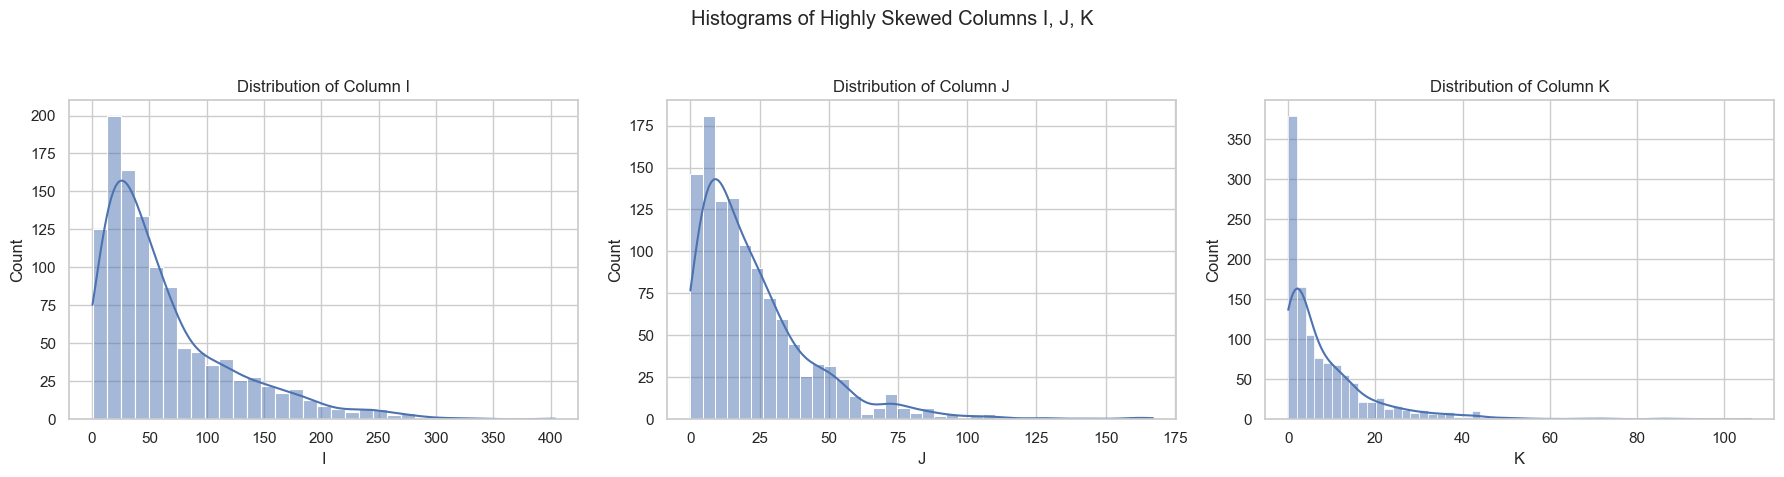

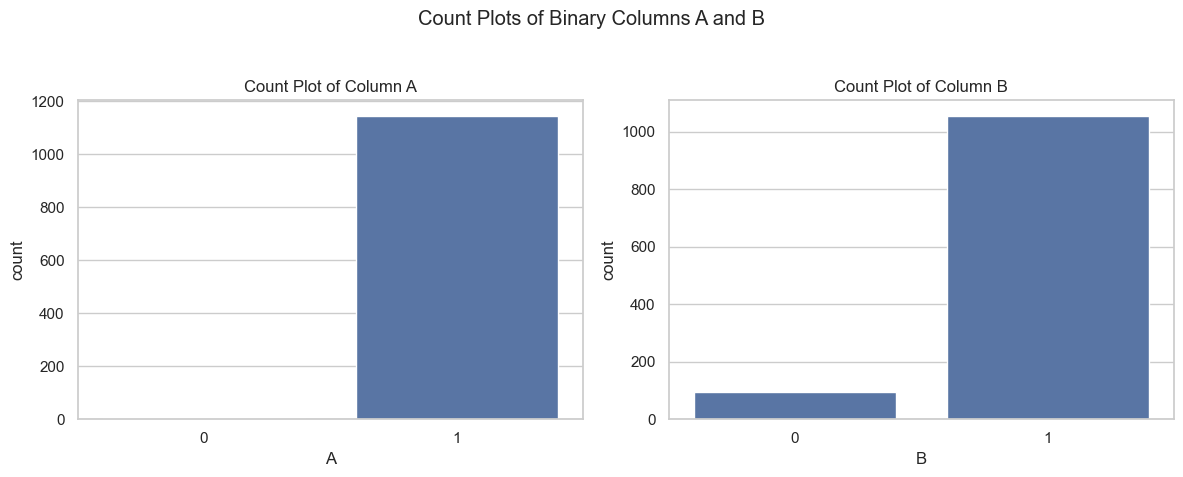

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_raw # Use df_raw as no df_clean or df_features are available

# Chart 1: Correlation Heatmap for columns C, D, E, F, G
plt.figure(figsize=(8, 6))
correlation_matrix = df[['C', 'D', 'E', 'F', 'G']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Columns C, D, E, F, G')
plt.tight_layout()
plt.show()
print("This heatmap visualizes the correlation between columns C, D, E, F, and G, revealing the strength and direction of their linear relationships.")

# Chart 2: Histograms for highly skewed columns I, J, K
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['I'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Column I')

sns.histplot(df['J'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Column J')

sns.histplot(df['K'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Column K')

plt.suptitle('Histograms of Highly Skewed Columns I, J, K')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
print("These histograms show the distributions of highly skewed columns I, J, and K, illustrating their long tails and concentration of data points towards lower values.")

# Chart 3: Count plots for binary columns A and B
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=df['A'], ax=axes[0])
axes[0].set_title('Count Plot of Column A')

sns.countplot(x=df['B'], ax=axes[1])
axes[1].set_title('Count Plot of Column B')

plt.suptitle('Count Plots of Binary Columns A and B')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
print("These count plots display the frequency of each category within binary columns A and B, showing the distribution of their two distinct values.")